# Q4 Evaluation and Discussion of Predictive Models

**Data provenance:** `PartB_Q3.ipynb` trains and tunes all four models on the same duplicate-free stratified split and shared TF-IDF matrices. It exports the held-out labels, predictions, model scores, cross-validation F1 values and fit times. This notebook loads that prediction-level evidence and independently calculates every Q4 metric and confusion-matrix count without repeating the expensive searches.

## 1. Evaluation evidence

Five complementary metrics are retained: accuracy, precision, recall, F1-score and ROC-AUC. 
The confusion-matrix counts are also included because aggregate scores can hide whether errors are false positives or false negatives. 
F1 was the tuning objective, but the final model is selected using converging evidence across all metrics and error counts.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

plt.style.use("seaborn-v0_8-whitegrid")
candidate_output_dirs = [
    Path.cwd(),
    Path.cwd() / "source" / "TSXA" / "Part_B_Q4_Evaluation",
    Path.cwd() / "TSXA" / "Part_B_Q4_Evaluation",
]
OUTPUT_DIR = next(
    (folder.resolve() for folder in candidate_output_dirs if (folder / "PartB_Q3.ipynb").exists()),
    Path.cwd().resolve(),
)
prediction_path = OUTPUT_DIR / "q3_test_predictions.csv"
metadata_path = OUTPUT_DIR / "q3_model_metadata.csv"
if not prediction_path.exists() or not metadata_path.exists():
    raise FileNotFoundError(
        "Run PartB_Q3.ipynb first to export q3_test_predictions.csv and q3_model_metadata.csv."
    )

prediction_df = pd.read_csv(prediction_path)
metadata_df = pd.read_csv(metadata_path).set_index("Model")
model_columns = {
    "Logistic Regression": "logistic_regression",
    "Naive Bayes": "naive_bayes",
    "Linear SVM": "linear_svm",
    "Random Forest": "random_forest",
}
required_columns = {"y_true"} | {
    f"{prefix}_{suffix}"
    for prefix in model_columns.values()
    for suffix in ("pred", "score")
}
missing_columns = required_columns.difference(prediction_df.columns)
if missing_columns:
    raise ValueError(f"Prediction export is missing columns: {sorted(missing_columns)}")
if prediction_df[list(required_columns)].isna().any().any():
    raise ValueError("Prediction export contains missing values.")

y_true = prediction_df["y_true"].astype(int)
if set(y_true.unique()) != {0, 1}:
    raise ValueError("y_true must contain both binary labels 0 and 1.")

metric_rows = []
error_rows = []
for model_name, prefix in model_columns.items():
    y_pred = prediction_df[f"{prefix}_pred"].astype(int)
    y_score = prediction_df[f"{prefix}_score"].astype(float)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    metric_rows.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_score),
        "CV F1": metadata_df.loc[model_name, "Best CV F1"],
        "Fit time (s)": metadata_df.loc[model_name, "Fit time (s)"],
    })
    error_rows.append({
        "Model": model_name, "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "Total errors": fp + fn,
    })

metrics_df = pd.DataFrame(metric_rows).set_index("Model")
errors_df = pd.DataFrame(error_rows).set_index("Model")

metrics_df.reset_index(names="Model").to_csv(
    OUTPUT_DIR / "q4_model_metrics.csv", index=False
)
errors_df.reset_index(names="Model").to_csv(
    OUTPUT_DIR / "q4_confusion_matrix_counts.csv", index=False
)

print(f"Calculated Q4 results for {len(metrics_df)} models from {len(y_true):,} held-out predictions.")

Calculated Q4 results for 4 models from 9,916 held-out predictions.


## 2. Model Performance and Confusion Matrix 

In [2]:
print("Held-out model performance (higher is better)")
display(metrics_df.round(4))

best_model = metrics_df["F1-score"].idxmax()
print(f"Selected model from converging evidence: {best_model}")

Held-out model performance (higher is better)


,Accuracy,Precision,Recall,F1-score,ROC-AUC,CV F1,Fit time (s)
Model,,,,,,,
Logistic Regression,0.8904,0.8829,0.9011,0.8919,0.9605,0.8939,0.3457
Naive Bayes,0.8632,0.8539,0.8774,0.8655,0.9378,0.8696,0.0161
Linear SVM,0.8923,0.8844,0.9036,0.8939,0.9612,0.8947,0.5662
Random Forest,0.8529,0.8210,0.9040,0.8605,0.9350,0.8499,4.8571


Selected model from converging evidence: Linear SVM


In [3]:
print("Confusion-matrix counts")
display(errors_df)

print(
    f"{best_model} produced the fewest errors: "
    f"{errors_df.loc[best_model, 'Total errors']:,}."
)

Confusion-matrix counts


,TN,FP,FN,TP,Total errors
Model,,,,,
Logistic Regression,4344,595,492,4485,1087
Naive Bayes,4192,747,610,4367,1357
Linear SVM,4351,588,480,4497,1068
Random Forest,3958,981,478,4499,1459


Linear SVM produced the fewest errors: 1,068.


## 3. Compact visual comparison

The dashboard uses a shared 0.80-1.00 scale for the predictive metrics, shows the two error types separately, and compares cross-validation F1 with held-out test F1. This makes the small Linear SVM-Logistic Regression difference visible without replacing the exact numerical tables.

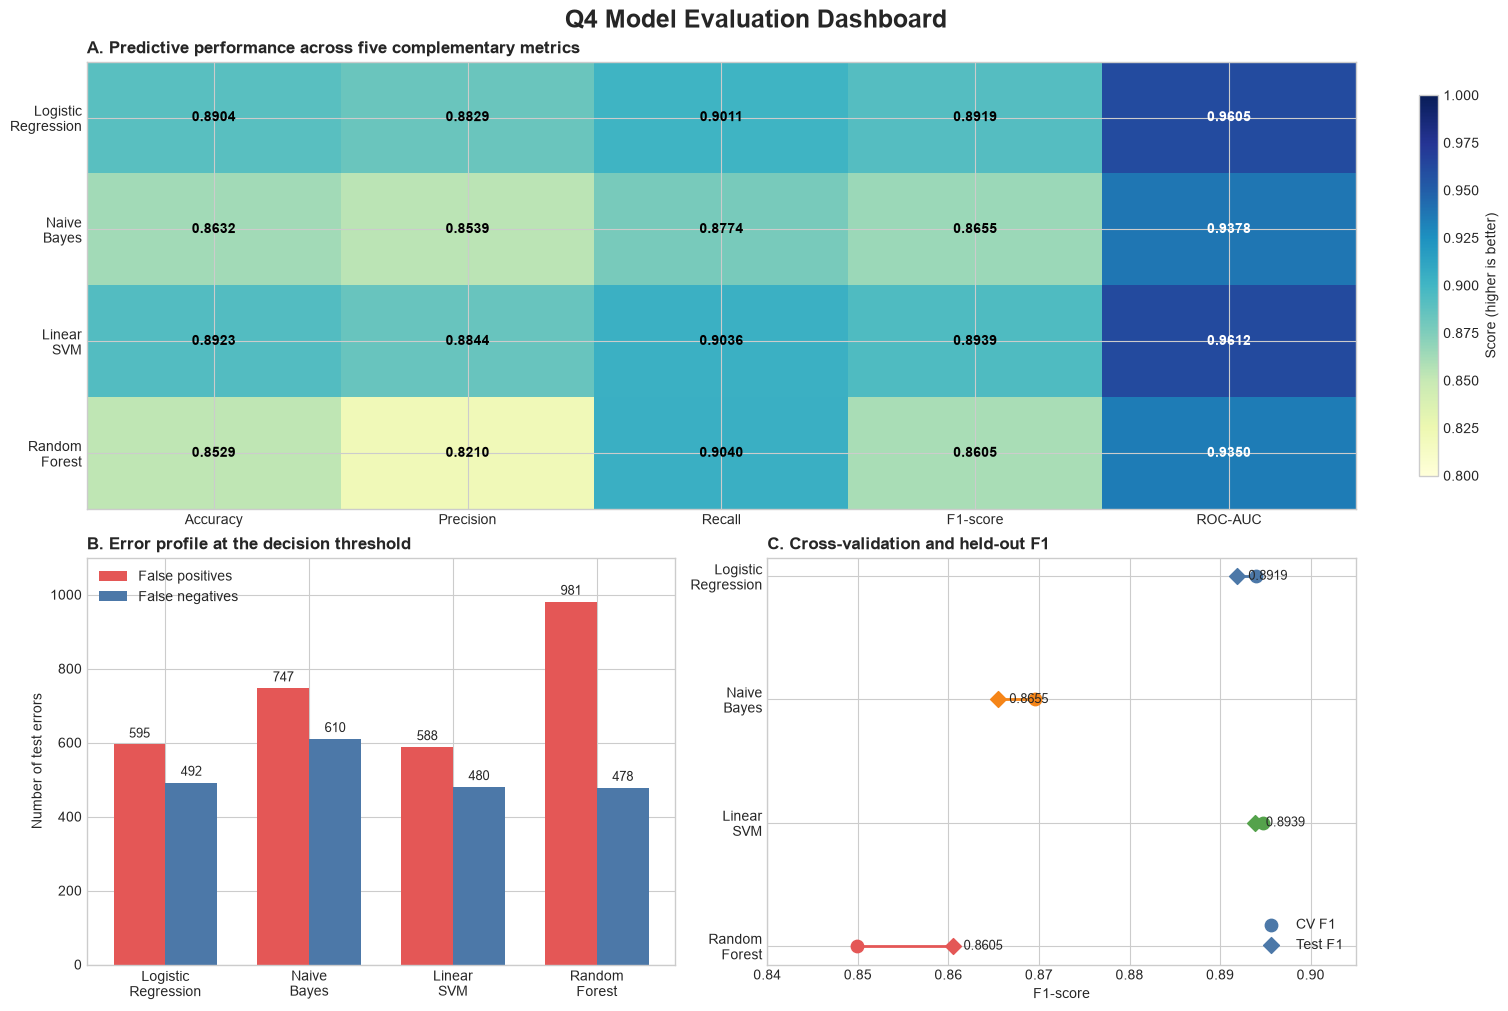

Saved report-ready dashboard: q4_model_evaluation_dashboard.png


In [4]:
model_labels = ["Logistic\nRegression", "Naive\nBayes", "Linear\nSVM", "Random\nForest"]
metric_columns = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
heat_values = metrics_df[metric_columns].to_numpy()
colors = ["#4C78A8", "#F58518", "#54A24B", "#E45756"]

fig = plt.figure(figsize=(15, 10), constrained_layout=True)
grid = fig.add_gridspec(2, 2, height_ratios=[1.1, 1.0])

# Panel A: common-scale metric heatmap
ax1 = fig.add_subplot(grid[0, :])
image = ax1.imshow(heat_values, cmap="YlGnBu", vmin=0.80, vmax=1.00, aspect="auto")
ax1.set_xticks(np.arange(len(metric_columns)), metric_columns)
ax1.set_yticks(np.arange(len(model_labels)), model_labels)
ax1.set_title("A. Predictive performance across five complementary metrics", loc="left", weight="bold")
for row in range(heat_values.shape[0]):
    for column in range(heat_values.shape[1]):
        value = heat_values[row, column]
        text_color = "white" if value >= 0.92 else "black"
        ax1.text(column, row, f"{value:.4f}", ha="center", va="center", color=text_color, weight="bold")
fig.colorbar(image, ax=ax1, label="Score (higher is better)", shrink=0.85)

# Panel B: error profile
ax2 = fig.add_subplot(grid[1, 0])
x = np.arange(len(model_labels))
width = 0.36
fp_bars = ax2.bar(x - width / 2, errors_df["FP"], width, label="False positives", color="#E45756")
fn_bars = ax2.bar(x + width / 2, errors_df["FN"], width, label="False negatives", color="#4C78A8")
ax2.set_xticks(x, model_labels)
ax2.set_ylabel("Number of test errors")
ax2.set_title("B. Error profile at the decision threshold", loc="left", weight="bold")
ax2.legend(frameon=False)
ax2.bar_label(fp_bars, padding=3, fontsize=9)
ax2.bar_label(fn_bars, padding=3, fontsize=9)
ax2.set_ylim(0, 1100)

# Panel C: validation-to-test consistency
ax3 = fig.add_subplot(grid[1, 1])
y = np.arange(len(model_labels))
for position, model in enumerate(metrics_df.index):
    cv_score = metrics_df.loc[model, "CV F1"]
    test_score = metrics_df.loc[model, "F1-score"]
    ax3.plot([cv_score, test_score], [position, position], color=colors[position], linewidth=2)
    ax3.scatter(cv_score, position, color=colors[position], marker="o", s=80, label="CV F1" if position == 0 else None)
    ax3.scatter(test_score, position, color=colors[position], marker="D", s=65, label="Test F1" if position == 0 else None)
    ax3.text(test_score + 0.0012, position, f"{test_score:.4f}", va="center", fontsize=9)
ax3.set_yticks(y, model_labels)
ax3.invert_yaxis()
ax3.set_xlim(0.84, 0.905)
ax3.set_xlabel("F1-score")
ax3.set_title("C. Cross-validation and held-out F1", loc="left", weight="bold")
ax3.legend(frameon=False, loc="lower right")

fig.suptitle("Q4 Model Evaluation Dashboard", fontsize=18, weight="bold")
figure_path = OUTPUT_DIR / "q4_model_evaluation_dashboard.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved report-ready dashboard:", figure_path.name)

## 4. Concise report-ready discussion

Linear SVM achieved the best overall performance, recording 89.23% accuracy, an F1-score of 89.39%, a ROC-AUC of 0.9612 and the fewest errors (1,068). Its cross-validation F1 (0.8947) was close to its test F1 (0.8939), supporting its selection under this experimental setup. However, its advantage over Logistic Regression was small: accuracy and F1 each improved by only 0.19 percentage points, and it produced 19 fewer errors. As no statistical test was performed, Linear SVM should be described as slightly better rather than significantly superior.

Naive Bayes was the fastest model but produced lower accuracy and F1. Random Forest achieved the highest recall at 90.40%, narrowly above Linear SVM's 90.36%, but generated 981 false positives compared with 588 for Linear SVM. Its resulting precision of 82.10% shows why recall should not be considered alone. Random Forest also received a smaller tuning budget, so its result is conditional on the tested search space.

The Linear SVM accuracy is close to the 89.16% bigram-SVM result of Wang and Manning (2012), while their specialised NB-SVM achieved 91.22%. Maas et al. (2011) reported 88.89% using sentiment-aware word representations with bag-of-words features. These comparisons are contextual because the earlier studies used the standard 25,000/25,000 IMDb split, whereas this experiment removed duplicates and used a stratified 80:20 split. Overall, Linear SVM provides the strongest combined predictive results, although Logistic Regression remains a closely competitive alternative.

## 5. Interpretation limits

- The Linear SVM and Logistic Regression difference was not tested for statistical significance.
- Only one held-out partition and one cleaned IMDb dataset were evaluated.
- Random Forest used a smaller tuning sample and search budget.
- The literature values use different splits and feature pipelines, so they are contextual benchmarks rather than direct rankings.